Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset from: /content/drive/MyDrive/MBP_PREDICTOR/data/features_cleaned_final.csv
Dataset shape: (3072, 1057)
Features: 1055
Target distribution: {0: 1539, 1: 1533}
Sample feature names: ['AAC_A', 'AAC_C', 'AAC_D', 'AAC_E', 'AAC_F']

CROSS-VALIDATION EVALUATION

Evaluating Logistic Regression with 5-Fold CV...
Logistic Regression Mean CV Accuracy: 0.8252 (+/- 0.0181)
Individual folds: ['0.7919', '0.8358', '0.8453', '0.8290', '0.8241']

Evaluating SVM with 5-Fold CV...
SVM Mean CV Accuracy: 0.7637 (+/- 0.0108)
Individual folds: ['0.7447', '0.7756', '0.7655', '0.7720', '0.7606']

Evaluating RandomForest with 5-Fold CV...
RandomForest Mean CV Accuracy: 0.8910 (+/- 0.0158)
Individual folds: ['0.8602', '0.9024', '0.8974', '0.9023', '0.8925']

Evaluating XGBoost with 5-Fold CV...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


XGBoost Mean CV Accuracy: 0.9111 (+/- 0.0142)
Individual folds: ['0.8846', '0.9220', '0.9235', '0.9169', '0.9088']

Evaluating LightGBM with 5-Fold CV...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


LightGBM Mean CV Accuracy: 0.9124 (+/- 0.0158)
Individual folds: ['0.8846', '0.9220', '0.9316', '0.9104', '0.9137']

Evaluating MLP with 5-Fold CV...
MLP Mean CV Accuracy: 0.8252 (+/- 0.0109)
Individual folds: ['0.8098', '0.8179', '0.8290', '0.8420', '0.8274']

MODEL RANKING
Cross-Validation Results (Ranked):
1. LightGBM             --> CV Accuracy: 0.9124 (+/- 0.0158)
2. XGBoost              --> CV Accuracy: 0.9111 (+/- 0.0142)
3. RandomForest         --> CV Accuracy: 0.8910 (+/- 0.0158)
4. Logistic Regression  --> CV Accuracy: 0.8252 (+/- 0.0181)
5. MLP                  --> CV Accuracy: 0.8252 (+/- 0.0109)
6. SVM                  --> CV Accuracy: 0.7637 (+/- 0.0108)

Top 3 models selected for final training and saving:
1. LightGBM: 0.9124
2. XGBoost: 0.9111
3. RandomForest: 0.8910

FINAL TRAINING ON TRAIN/TEST SPLIT
Training set: (2457, 1055)
Test set: (615, 1055)

Training final LightGBM model...
Test Accuracy: 0.9203 (92.03%)
Classification Report:
              precision    recall

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [03:38:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Accuracy: 0.9154 (91.54%)
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       308
           1       0.89      0.94      0.92       307

    accuracy                           0.92       615
   macro avg       0.92      0.92      0.92       615
weighted avg       0.92      0.92      0.92       615


Training final RandomForest model...
Test Accuracy: 0.8976 (89.76%)
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       308
           1       0.87      0.93      0.90       307

    accuracy                           0.90       615
   macro avg       0.90      0.90      0.90       615
weighted avg       0.90      0.90      0.90       615


SAVING TOP 3 MODELS
Saved: LightGBM_CV0.9124_Test0.9203.pkl
Saved: XGBoost_CV0.9111_Test0.9154.pkl
Saved: RandomForest_CV0.8910_Test0.8976.pkl

All models saved to: /content/drive/MyDrive/MBP_PREDICT

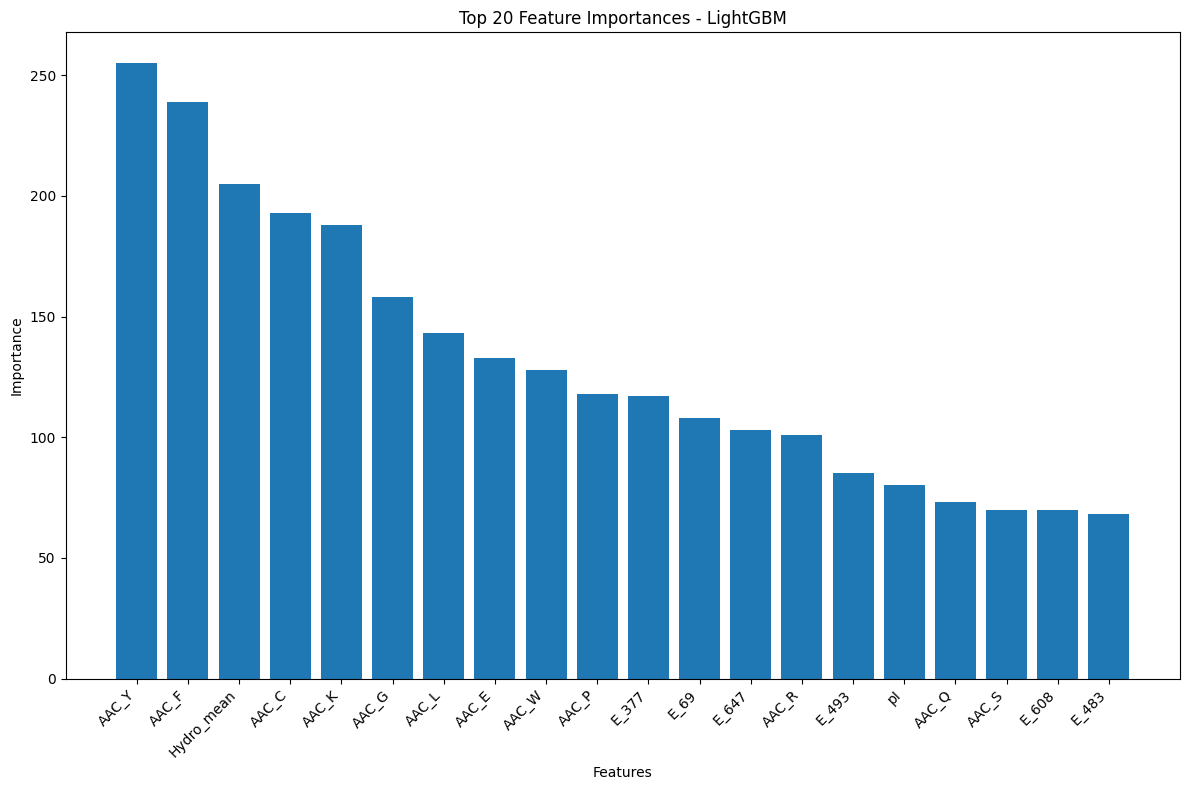


Top 20 Most Important Features:
 1. AAC_Y                          --> 255.000000
 2. AAC_F                          --> 239.000000
 3. Hydro_mean                     --> 205.000000
 4. AAC_C                          --> 193.000000
 5. AAC_K                          --> 188.000000
 6. AAC_G                          --> 158.000000
 7. AAC_L                          --> 143.000000
 8. AAC_E                          --> 133.000000
 9. AAC_W                          --> 128.000000
10. AAC_P                          --> 118.000000
11. E_377                          --> 117.000000
12. E_69                           --> 108.000000
13. E_647                          --> 103.000000
14. AAC_R                          --> 101.000000
15. E_493                          --> 85.000000
16. pI                             --> 80.000000
17. AAC_Q                          --> 73.000000
18. AAC_S                          --> 70.000000
19. E_608                          --> 70.000000
20. E_483             

In [2]:
# ============================================================
# MBP Predictor - Training Pipeline with Cross-Validation (Colab)
# ============================================================

from google.colab import drive
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

# Mount Google Drive
drive.mount('/content/drive')

# ============================================================
# 1. Setup Paths and Load Dataset
# ============================================================
BASE_PATH = "/content/drive/MyDrive/MBP_PREDICTOR"
DATA_PATH = os.path.join(BASE_PATH, "data/features_cleaned_final.csv")
MODEL_DIR = os.path.join(BASE_PATH, "TRAINED_MODELS")

# Create model directory
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Loading dataset from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")

# Prepare features and target
target_col = "Label"
feature_cols = [col for col in df.columns if col not in [target_col, 'Protein_ID']]

# Sanitize feature names (remove special characters that XGBoost doesn't like)
def sanitize_feature_name(name):
    """Remove characters that XGBoost doesn't accept: [, ], <, >"""
    return name.replace('[', '_').replace(']', '_').replace('<', '_').replace('>', '_')

# Create mapping of old to new names
feature_mapping = {col: sanitize_feature_name(col) for col in feature_cols}
df_clean = df.rename(columns=feature_mapping)

# Update feature columns with sanitized names
feature_cols_clean = [feature_mapping[col] for col in feature_cols]

X = df_clean[feature_cols_clean]
y = df_clean[target_col]

print(f"Features: {len(feature_cols_clean)}")
print(f"Target distribution: {y.value_counts().to_dict()}")
print(f"Sample feature names: {feature_cols_clean[:5]}")

# ============================================================
# 2. Define Models (Optimized Parameters)
# ============================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, solver="lbfgs", random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, C=10, gamma='scale', random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss",
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=50,
        feature_fraction=0.9,
        bagging_fraction=0.9,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )
}

# ============================================================
# 3. Cross-Validation Evaluation
# ============================================================
print("\n" + "="*60)
print("CROSS-VALIDATION EVALUATION")
print("="*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    print(f"\nEvaluating {name} with 5-Fold CV...")

    # Cross-validation scores
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    mean_acc = np.mean(cv_scores)
    std_acc = np.std(cv_scores)

    results[name] = {
        'mean_accuracy': mean_acc,
        'std_accuracy': std_acc,
        'cv_scores': cv_scores
    }

    print(f"{name} Mean CV Accuracy: {mean_acc:.4f} (+/- {std_acc:.4f})")
    print(f"Individual folds: {[f'{score:.4f}' for score in cv_scores]}")

# ============================================================
# 4. Rank Models and Select Top 3
# ============================================================
print("\n" + "="*60)
print("MODEL RANKING")
print("="*60)

# Sort models by mean accuracy
sorted_results = sorted(results.items(), key=lambda x: x[1]['mean_accuracy'], reverse=True)

print("Cross-Validation Results (Ranked):")
for i, (name, result) in enumerate(sorted_results, 1):
    mean_acc = result['mean_accuracy']
    std_acc = result['std_accuracy']
    print(f"{i}. {name:20s} --> CV Accuracy: {mean_acc:.4f} (+/- {std_acc:.4f})")

# Get top 3 models
top_3_models = sorted_results[:3]
print(f"\nTop 3 models selected for final training and saving:")
for i, (name, result) in enumerate(top_3_models, 1):
    print(f"{i}. {name}: {result['mean_accuracy']:.4f}")

# ============================================================
# 5. Train Top 3 Models on Train/Test Split
# ============================================================
print("\n" + "="*60)
print("FINAL TRAINING ON TRAIN/TEST SPLIT")
print("="*60)

# Create train-test split for final evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

final_results = []

for name, cv_result in top_3_models:
    print(f"\nTraining final {name} model...")

    # Get the model
    model = models[name]

    # Train on full training set
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)

    print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Store results
    final_results.append((name, cv_result['mean_accuracy'], test_accuracy, model))

# ============================================================
# 6. Save Top 3 Models
# ============================================================
print("\n" + "="*60)
print("SAVING TOP 3 MODELS")
print("="*60)

for name, cv_acc, test_acc, model in final_results:
    # Save model with both CV and test accuracy in filename
    filename = f"{name}_CV{cv_acc:.4f}_Test{test_acc:.4f}.pkl"
    save_path = os.path.join(MODEL_DIR, filename)
    joblib.dump(model, save_path)
    print(f"Saved: {filename}")

print(f"\nAll models saved to: {MODEL_DIR}")

# ============================================================
# 7. Feature Importance Analysis (Best Tree-based Model)
# ============================================================
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Find the best tree-based model
best_model_name, best_cv_acc, best_test_acc, best_model = final_results[0]

if best_model_name in ["RandomForest", "XGBoost", "LightGBM"]:
    print(f"Analyzing feature importance for {best_model_name}...")

    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1][:20]  # Top 20 features

    # Plot feature importance
    plt.figure(figsize=(12, 8))
    plt.bar(range(len(indices)), importances[indices], align="center")
    plt.xticks(range(len(indices)), [feature_cols_clean[i] for i in indices], rotation=45, ha='right')
    plt.title(f"Top 20 Feature Importances - {best_model_name}")
    plt.xlabel("Features")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()

    # Print top features
    print("\nTop 20 Most Important Features:")
    for i, idx in enumerate(indices, 1):
        feature_name = feature_cols_clean[idx]
        importance = importances[idx]
        print(f"{i:2d}. {feature_name:30s} --> {importance:.6f}")

else:
    print(f"Feature importance not available for {best_model_name}")

# ============================================================
# 8. Final Summary
# ============================================================
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print("Top 3 Models Performance:")
for i, (name, cv_acc, test_acc, model) in enumerate(final_results, 1):
    print(f"{i}. {name}:")
    print(f"   CV Accuracy:   {cv_acc:.4f} ({cv_acc*100:.2f}%)")
    print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

best_name, best_cv, best_test, best_model = final_results[0]
print(f"\nBest Model: {best_name}")
print(f"Best Test Accuracy: {best_test:.4f} ({best_test*100:.2f}%)")

if best_test >= 0.94:
    print("EXCELLENT: Achieved 94%+ accuracy!")
elif best_test >= 0.92:
    print("GREAT: Achieved 92%+ accuracy!")
elif best_test >= 0.90:
    print("SUCCESS: Achieved 90%+ accuracy target!")
else:
    print(f"Close: {(0.90 - best_test)*100:.2f}% away from 90% target")

print(f"\nModels saved in: {MODEL_DIR}")
print("Training pipeline complete!")